# CRM Müşteri Veri Seti — Keşifsel Veri Analizi (EDA)

**Amaç:** Bu notebook, CRM müşteri veri setini önce *tanıtır ve görselleştirir*, ardından
*analiz eder*. Üç temel iş kolunun (segmentasyon, churn tahmini, davranış analizi) öncesinde
veriyi anlamayı ve veri kalitesi sorunlarını ortaya çıkarmayı hedefler.

**İçerik**
1. Kütüphaneler ve ayarlar
2. Veriyi yükleme ve ilk bakış
3. Eksik değer analizi
4. Veri kalitesi kontrolü (anomaliler)
5. Hedef değişken (Churn) analizi
6. Sayısal değişkenlerin dağılımı
7. Kategorik değişkenlerin dağılımı
8. Korelasyon analizi
9. Churn ile ilişki (iki değişkenli analiz)
10. Davranışsal içgörüler — RFM bakışı
11. Özet bulgular


## 1. Kütüphaneler ve Ayarlar

In [1]:
# Colab kullanıyorsan dosyayı yüklemek için:
# from google.colab import files; files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Tutarlı bir churn renk paleti
CHURN_PALETTE = {0: "#4C9F70", 1: "#D1495B"}  # 0 = kalan, 1 = ayrılan
print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 2. Veriyi Yükleme ve İlk Bakış

Veri setini yükleyip boyut, kolonlar, veri tipleri ve temel istatistiklerle tanıyalım.

In [2]:
DATA_PATH = "customers.csv"   # Colab'da dosyayı notebook ile aynı dizine koy

df = pd.read_csv(DATA_PATH)
print(f"Satır sayısı : {df.shape[0]:,}")
print(f"Kolon sayısı : {df.shape[1]}")
df.head()

Satır sayısı : 50,000
Kolon sayısı : 28


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,name,email,phone
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1,Customer0,customer07370@example.com,+1-555-392-7272
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4,Customer1,customer1960@example.com,+1-555-836-2109
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4,Customer2,customer25490@example.com,+1-555-570-6150
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1,Customer3,customer35291@example.com,+1-555-150-6268
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4,Customer4,customer45834@example.com,+1-555-619-5651


In [3]:
# Kolon tipleri ve dolu kayıt sayıları
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [4]:
# Sayısal değişkenlerin özet istatistikleri
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.80,11.83,5.00,29.00,38.00,46.00,200.00
Membership_Years,50000.0,2.98,2.06,0.10,1.40,2.50,4.00,10.00
Login_Frequency,50000.0,11.62,7.81,0.00,6.00,11.00,17.00,46.00
Session_Duration_Avg,46601.0,27.66,10.87,1.00,19.70,26.80,34.70,75.60
Pages_Per_Session,47000.0,8.74,3.78,1.00,6.00,8.40,11.20,24.10
Cart_Abandonment_Rate,50000.0,57.08,16.28,0.00,46.40,58.10,68.70,143.74
Wishlist_Items,46000.0,4.30,3.19,0.00,2.00,4.00,6.00,28.00
Total_Purchases,50000.0,13.11,7.02,-13.00,8.00,12.00,17.00,128.70
Average_Order_Value,50000.0,123.12,175.57,26.38,87.05,112.97,144.44,9666.38
Days_Since_Last_Purchase,47000.0,29.79,29.70,0.00,9.00,21.00,41.00,287.00


Kolonları rolüne göre ayıralım. `name`, `email`, `phone` kişisel tanımlayıcı bilgidir (PII);
modellemede kullanılmaz, yalnızca kayıt eşlemesi içindir.

In [5]:
TARGET = "Churned"
ID_COLS = ["name", "email", "phone"]
CATEGORICAL = ["Gender", "Country", "City", "Signup_Quarter"]
NUMERIC = [c for c in df.columns
           if c not in ID_COLS + CATEGORICAL + [TARGET]]

print("Hedef       :", TARGET)
print("Kategorik   :", CATEGORICAL)
print("Sayısal     :", len(NUMERIC), "kolon")
print("  ->", NUMERIC)
print("Kimlik(PII) :", ID_COLS)

Hedef       : Churned
Kategorik   : ['Gender', 'Country', 'City', 'Signup_Quarter']
Sayısal     : 20 kolon
  -> ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']
Kimlik(PII) : ['name', 'email', 'phone']


## 3. Eksik Değer Analizi

Davranışsal kolonların birçoğunda eksik değer var. Doldurma (imputation) stratejisini
belirlemek için önce eksikliğin boyutunu görselleştirelim.

In [6]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = (pd.DataFrame({"eksik_sayi": missing, "eksik_yuzde": missing_pct})
              .query("eksik_sayi > 0")
              .sort_values("eksik_yuzde", ascending=False))
missing_df

,eksik_sayi,eksik_yuzde
Social_Media_Engagement_Score,6000,12.00
Credit_Balance,5500,11.00
Mobile_App_Usage,5000,10.00
Returns_Rate,4491,8.98
Wishlist_Items,4000,8.00
Discount_Usage_Rate,3500,7.00
Product_Reviews_Written,3500,7.00
Session_Duration_Avg,3399,6.80
Pages_Per_Session,3000,6.00
Days_Since_Last_Purchase,3000,6.00


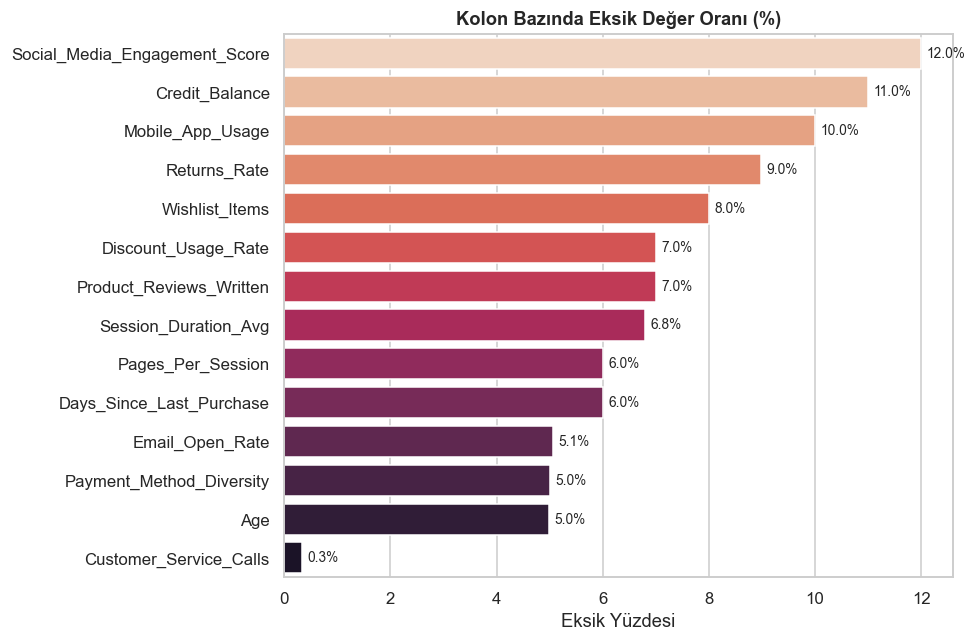

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x="eksik_yuzde", y=missing_df.index, data=missing_df,
            palette="rocket_r", ax=ax)
ax.set_title("Kolon Bazında Eksik Değer Oranı (%)")
ax.set_xlabel("Eksik Yüzdesi")
ax.set_ylabel("")
for i, v in enumerate(missing_df["eksik_yuzde"]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

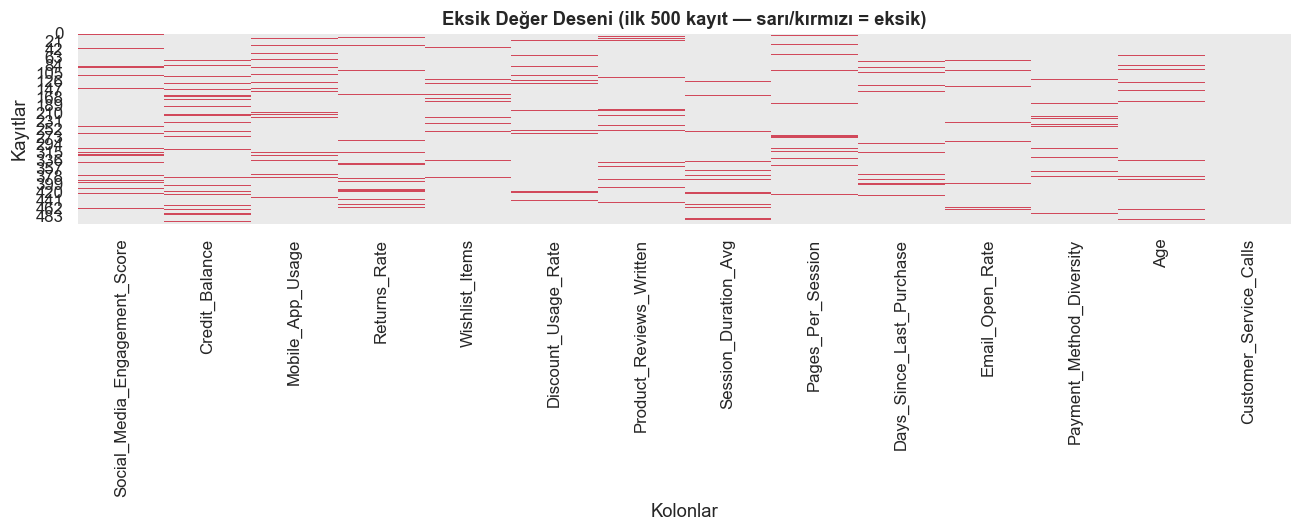

In [8]:
# Eksiklik deseni: rastgele mi yoksa belirli kayıtlarda mı kümeleniyor?
plt.figure(figsize=(12, 5))
sns.heatmap(df[missing_df.index].isna().iloc[:500],
            cbar=False, cmap=["#EAEAEA", "#D1495B"])
plt.title("Eksik Değer Deseni (ilk 500 kayıt — sarı/kırmızı = eksik)")
plt.xlabel("Kolonlar"); plt.ylabel("Kayıtlar")
plt.tight_layout()
plt.show()

## 4. Veri Kalitesi Kontrolü

Özet istatistiklerde mantıken imkânsız değerler dikkat çekiyor. Bunları modellemeden önce
işaretlemek gerekir (örn. yaş 200, negatif satın alma, %100'ü aşan sepet terk oranı).

In [9]:
issues = {}

# Yaş aralığı dışı (makul aralık: 13–100)
issues["Age < 13 veya > 100"] = int(((df["Age"] < 13) | (df["Age"] > 100)).sum())

# Negatif satın alma (imkânsız)
issues["Total_Purchases < 0"] = int((df["Total_Purchases"] < 0).sum())

# Oran kolonu %100'ü aşıyor
issues["Cart_Abandonment_Rate > 100"] = int((df["Cart_Abandonment_Rate"] > 100).sum())

# Yüzde olması beklenen diğer kolonlar
for c in ["Returns_Rate", "Discount_Usage_Rate", "Email_Open_Rate"]:
    issues[f"{c} > 100"] = int((df[c] > 100).sum())

# Duplike e-posta
issues["Duplike e-posta"] = int(df["email"].duplicated().sum())

quality = pd.Series(issues, name="kayit_sayisi").to_frame()
quality["yuzde"] = (quality["kayit_sayisi"] / len(df) * 100).round(3)
quality

,kayit_sayisi,yuzde
Age < 13 veya > 100,50,0.100
Total_Purchases < 0,40,0.080
Cart_Abandonment_Rate > 100,30,0.060
Returns_Rate > 100,0,0.000
Discount_Usage_Rate > 100,207,0.414
Email_Open_Rate > 100,0,0.000
Duplike e-posta,1,0.002


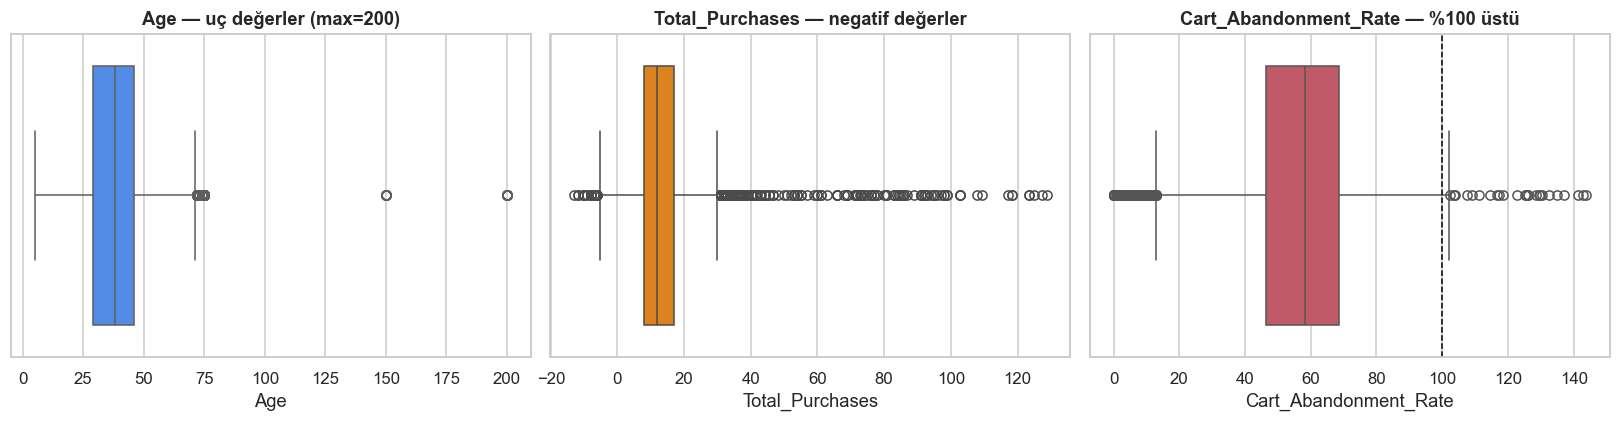

In [10]:
# Aykırı değerleri görsel olarak gösterelim
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df["Age"], color="#3A86FF", ax=axes[0])
axes[0].set_title("Age — uç değerler (max=200)")
sns.boxplot(x=df["Total_Purchases"], color="#FB8500", ax=axes[1])
axes[1].set_title("Total_Purchases — negatif değerler")
sns.boxplot(x=df["Cart_Abandonment_Rate"], color="#D1495B", ax=axes[2])
axes[2].axvline(100, color="black", ls="--", lw=1)
axes[2].set_title("Cart_Abandonment_Rate — %100 üstü")
plt.tight_layout()
plt.show()

## 5. Hedef Değişken: Churn Dağılımı

`Churned = 1` müşterinin ayrıldığını gösterir. Hafif bir sınıf dengesizliği var; bu,
churn modellemesinde `class_weight` / `scale_pos_weight` ve PR-AUC metriği gerektirir.

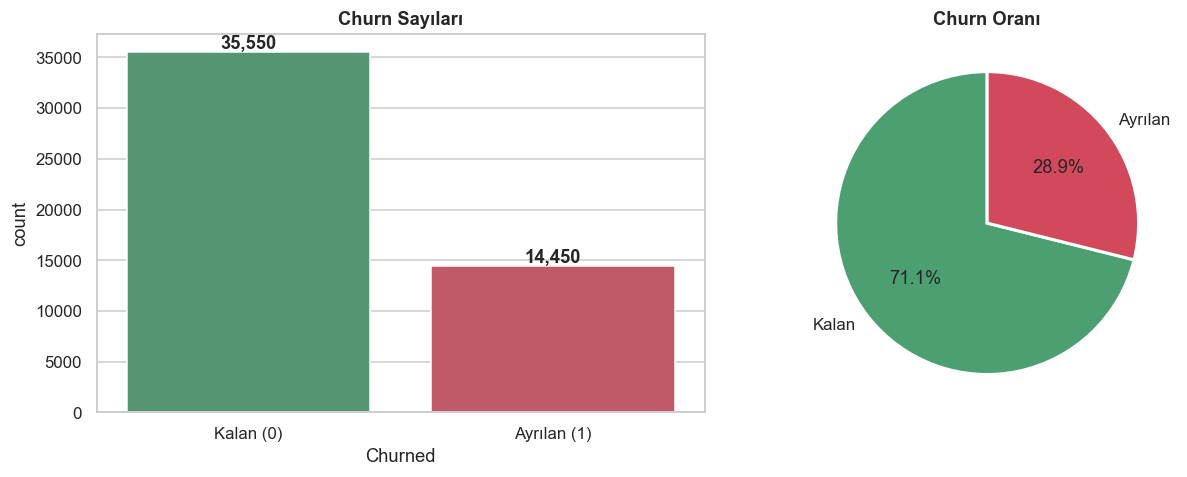

Churn oranı: %28.9


In [11]:
churn_counts = df[TARGET].value_counts().sort_index()
churn_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=TARGET, data=df, hue=TARGET, palette=CHURN_PALETTE,
              legend=False, ax=axes[0])
axes[0].set_title("Churn Sayıları")
axes[0].set_xticklabels(["Kalan (0)", "Ayrılan (1)"])
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(churn_pct, labels=["Kalan", "Ayrılan"], autopct="%1.1f%%",
            colors=[CHURN_PALETTE[0], CHURN_PALETTE[1]], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn Oranı")
plt.tight_layout()
plt.show()

print(f"Churn oranı: %{churn_pct[1]:.1f}")

## 6. Sayısal Değişkenlerin Dağılımı

Tüm sayısal kolonların histogramları — çarpıklık, kuyruklar ve olası dönüşüm ihtiyacı
(örn. log) buradan okunur.

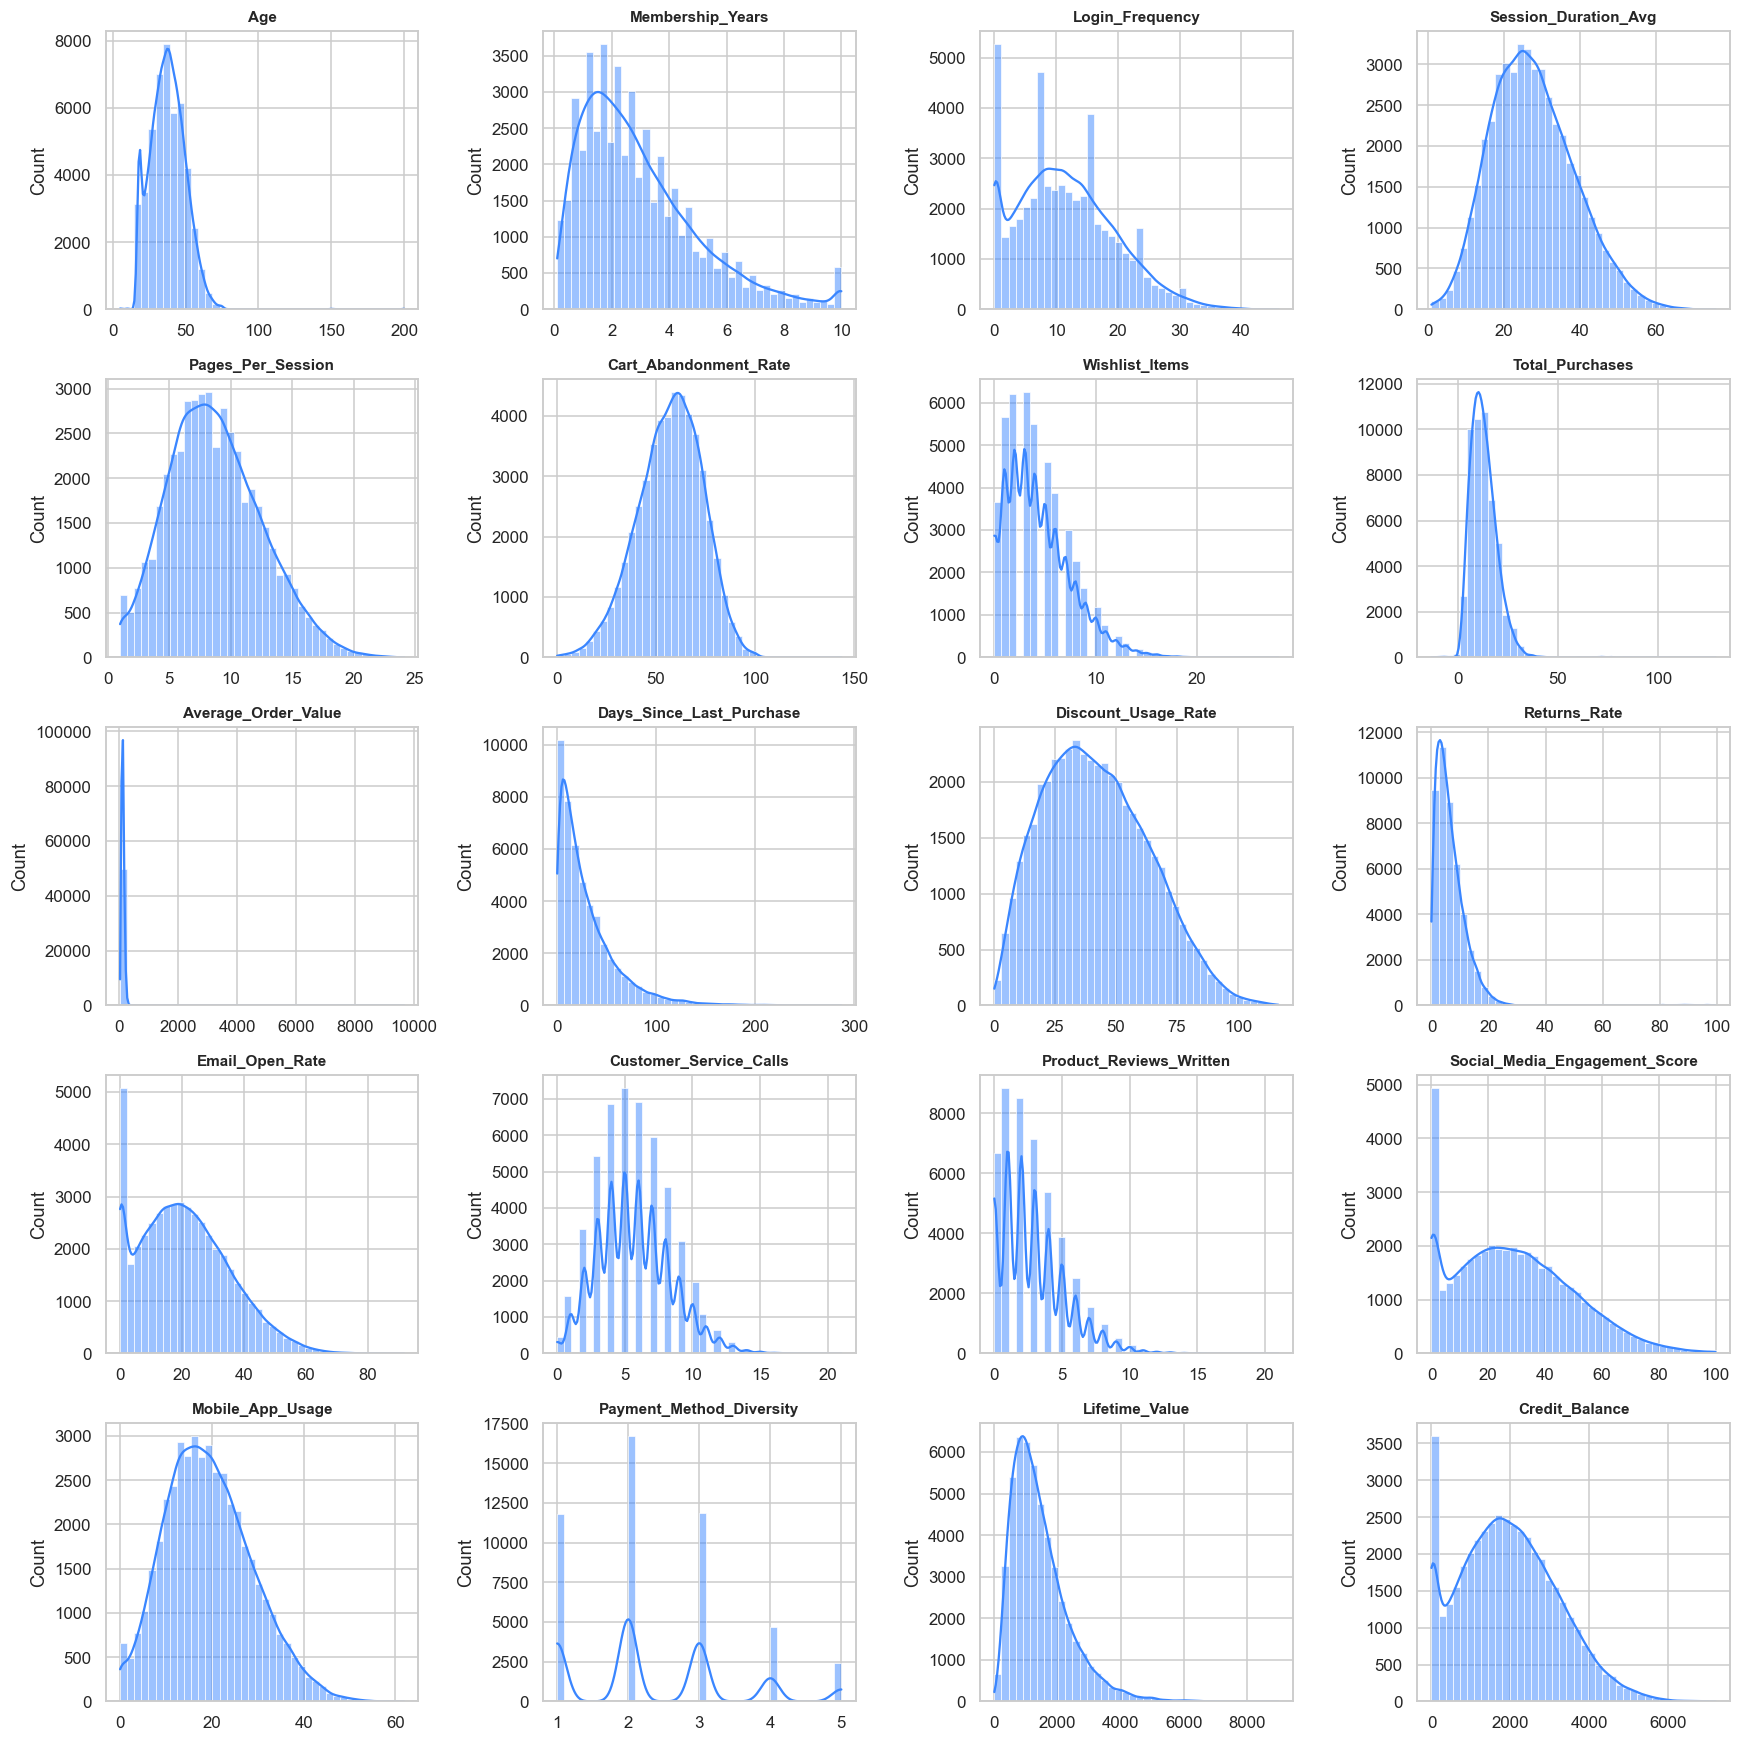

In [12]:
n = len(NUMERIC)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    sns.histplot(df[col].dropna(), kde=True, color="#3A86FF",
                 ax=axes[i], bins=40)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 7. Kategorik Değişkenlerin Dağılımı

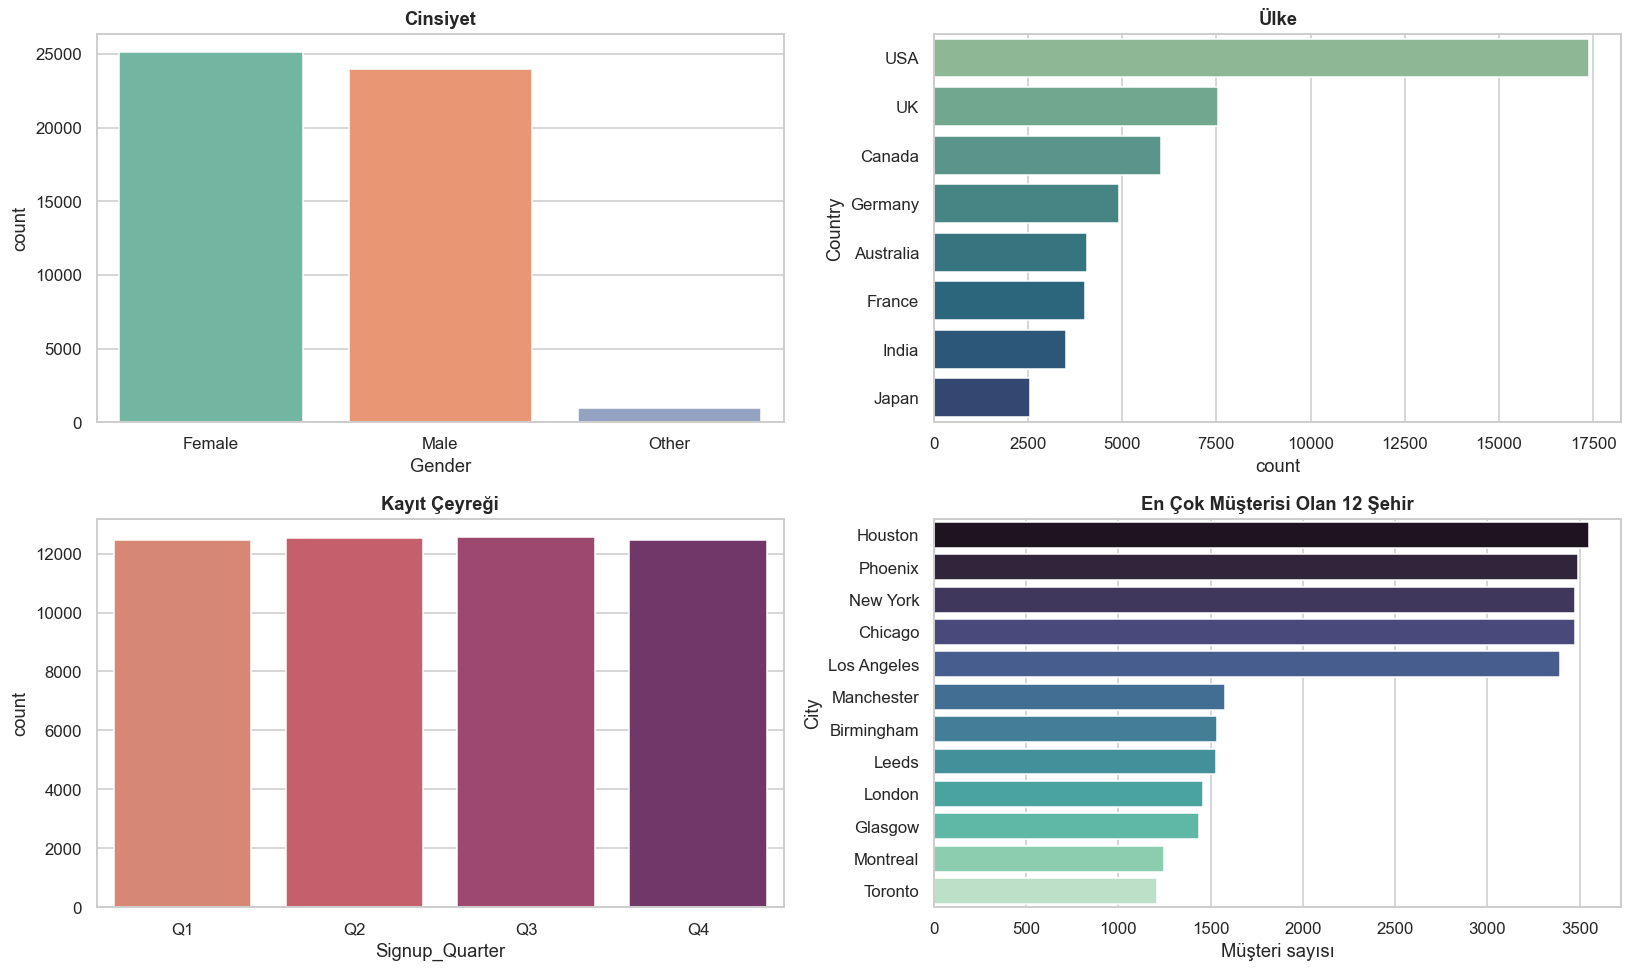

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.countplot(x="Gender", data=df, palette="Set2", ax=axes[0, 0],
              order=df["Gender"].value_counts().index)
axes[0, 0].set_title("Cinsiyet")

sns.countplot(y="Country", data=df, palette="crest", ax=axes[0, 1],
              order=df["Country"].value_counts().index)
axes[0, 1].set_title("Ülke")

sns.countplot(x="Signup_Quarter", data=df, palette="flare", ax=axes[1, 0],
              order=["Q1", "Q2", "Q3", "Q4"])
axes[1, 0].set_title("Kayıt Çeyreği")

top_cities = df["City"].value_counts().head(12)
sns.barplot(x=top_cities.values, y=top_cities.index, palette="mako",
            ax=axes[1, 1])
axes[1, 1].set_title("En Çok Müşterisi Olan 12 Şehir")
axes[1, 1].set_xlabel("Müşteri sayısı")

plt.tight_layout()
plt.show()

## 8. Korelasyon Analizi

Sayısal değişkenler arasındaki Pearson korelasyonu. Hem çoklu doğrusal bağlantı (multicollinearity)
hem de churn ile ilişkili kolonları görmek için.

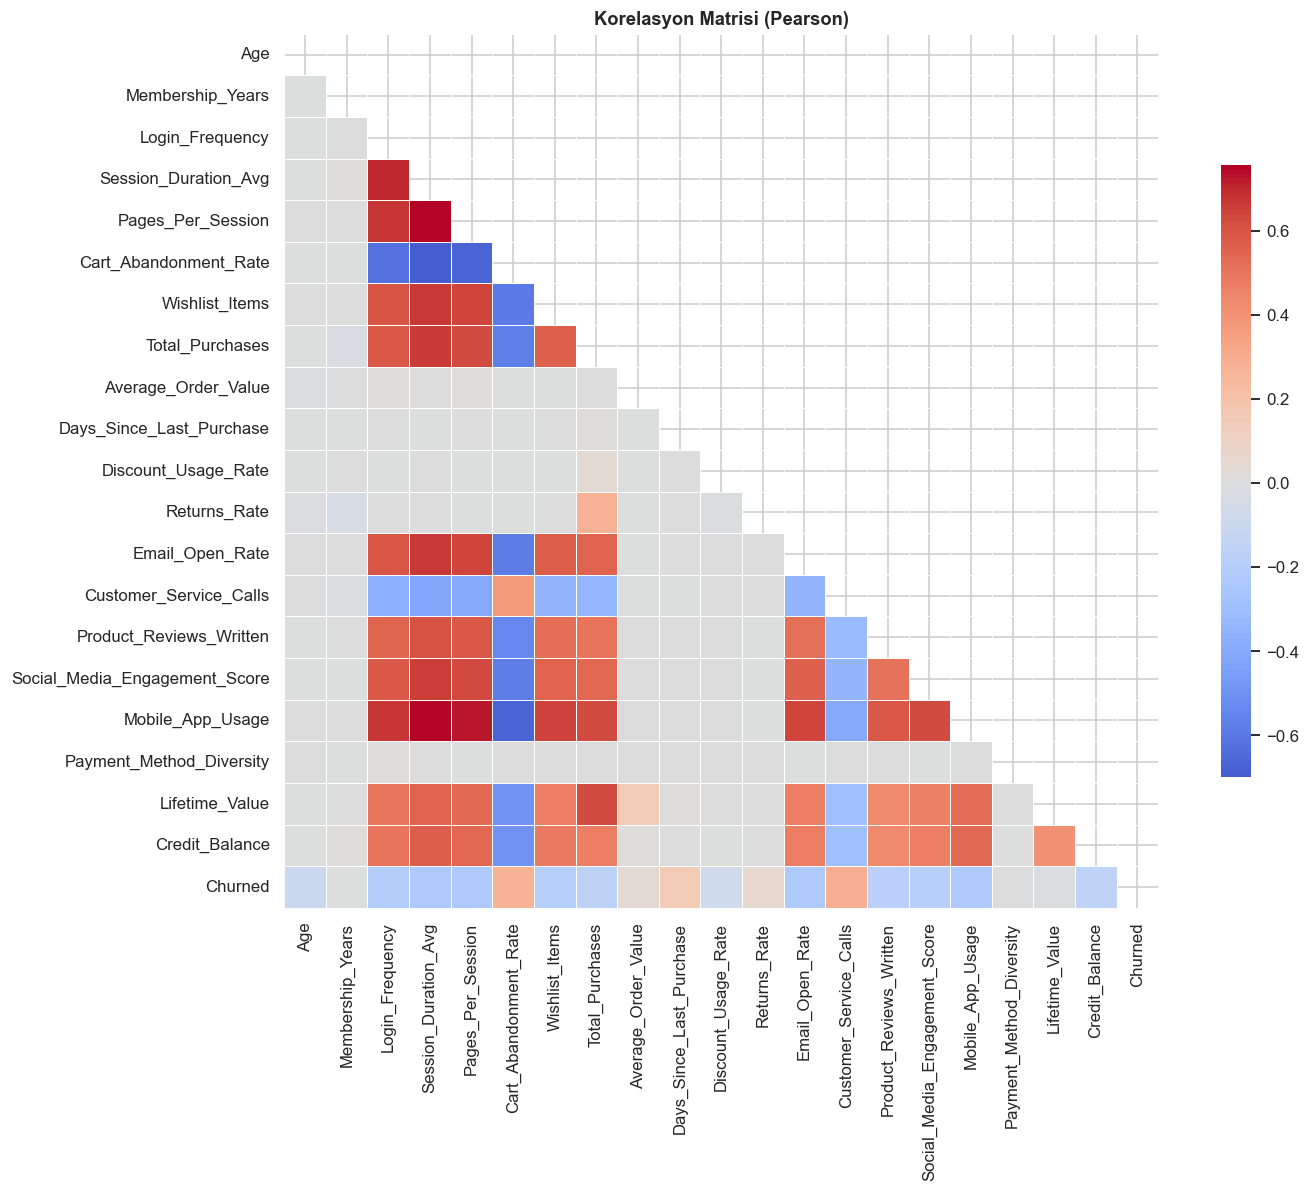

In [14]:
corr = df[NUMERIC + [TARGET]].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7})
plt.title("Korelasyon Matrisi (Pearson)")
plt.tight_layout()
plt.show()

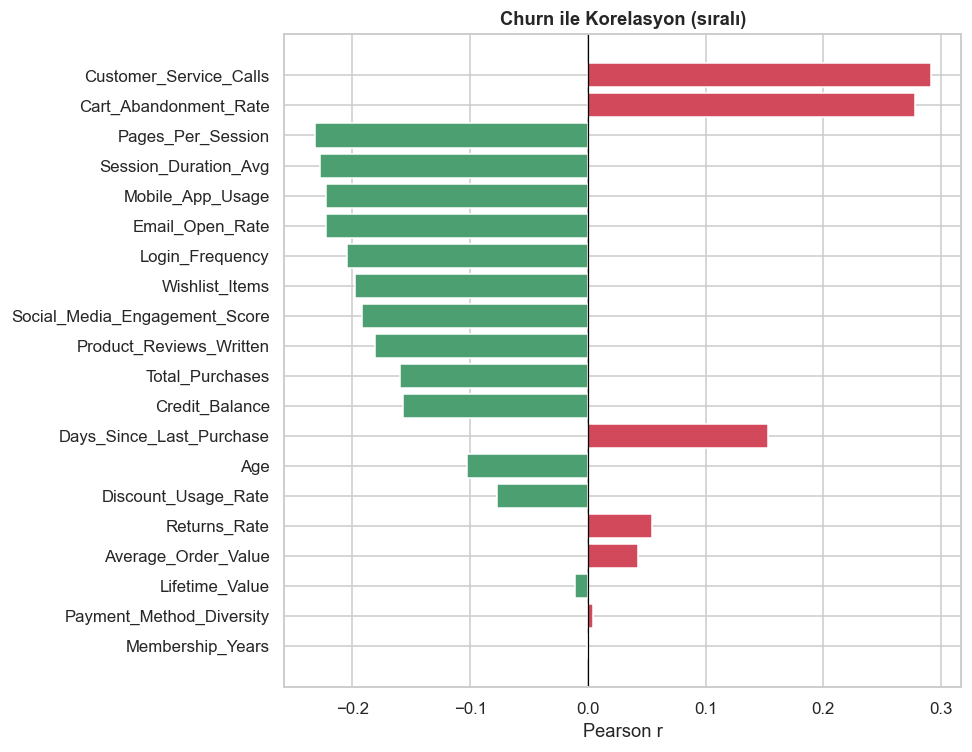

Not: Days_Since_Last_Purchase gibi kolonlar churn TANIMINA bağlı olarak
sızıntı (leakage) taşıyabilir. Yüksek korelasyon görürsen etiket tanımını doğrula.


In [15]:
# Churn ile en güçlü ilişkili değişkenler
churn_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 7))
colors = ["#D1495B" if v > 0 else "#4C9F70" for v in churn_corr]
plt.barh(churn_corr.index, churn_corr.values, color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color="black", lw=0.8)
plt.title("Churn ile Korelasyon (sıralı)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print("Not: Days_Since_Last_Purchase gibi kolonlar churn TANIMINA bağlı olarak")
print("sızıntı (leakage) taşıyabilir. Yüksek korelasyon görürsen etiket tanımını doğrula.")

## 9. Churn ile İlişki (İki Değişkenli Analiz)

Hangi davranışsal ve kategorik özellikler ayrılan müşterileri ayırt ediyor?

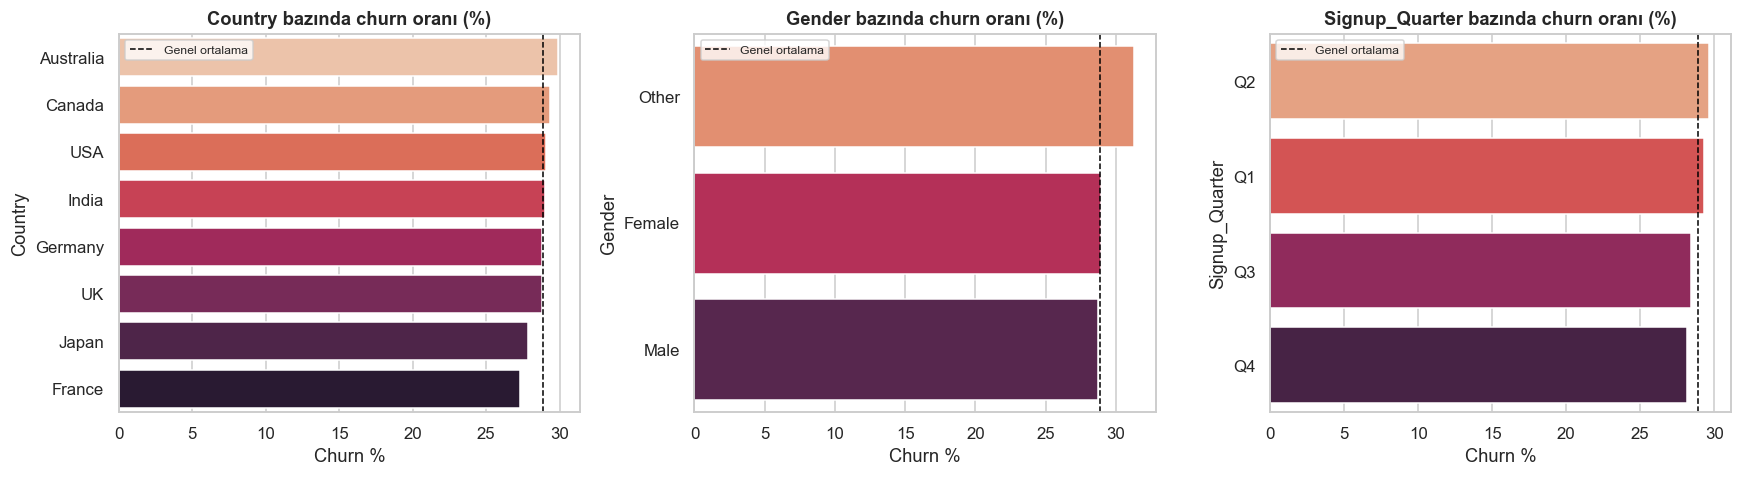

In [16]:
# Kategorik kırılımlarda churn oranı
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ["Country", "Gender", "Signup_Quarter"]):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, palette="rocket_r", ax=ax)
    ax.axvline(df[TARGET].mean() * 100, color="black", ls="--", lw=1,
               label="Genel ortalama")
    ax.set_title(f"{col} bazında churn oranı (%)")
    ax.set_xlabel("Churn %")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

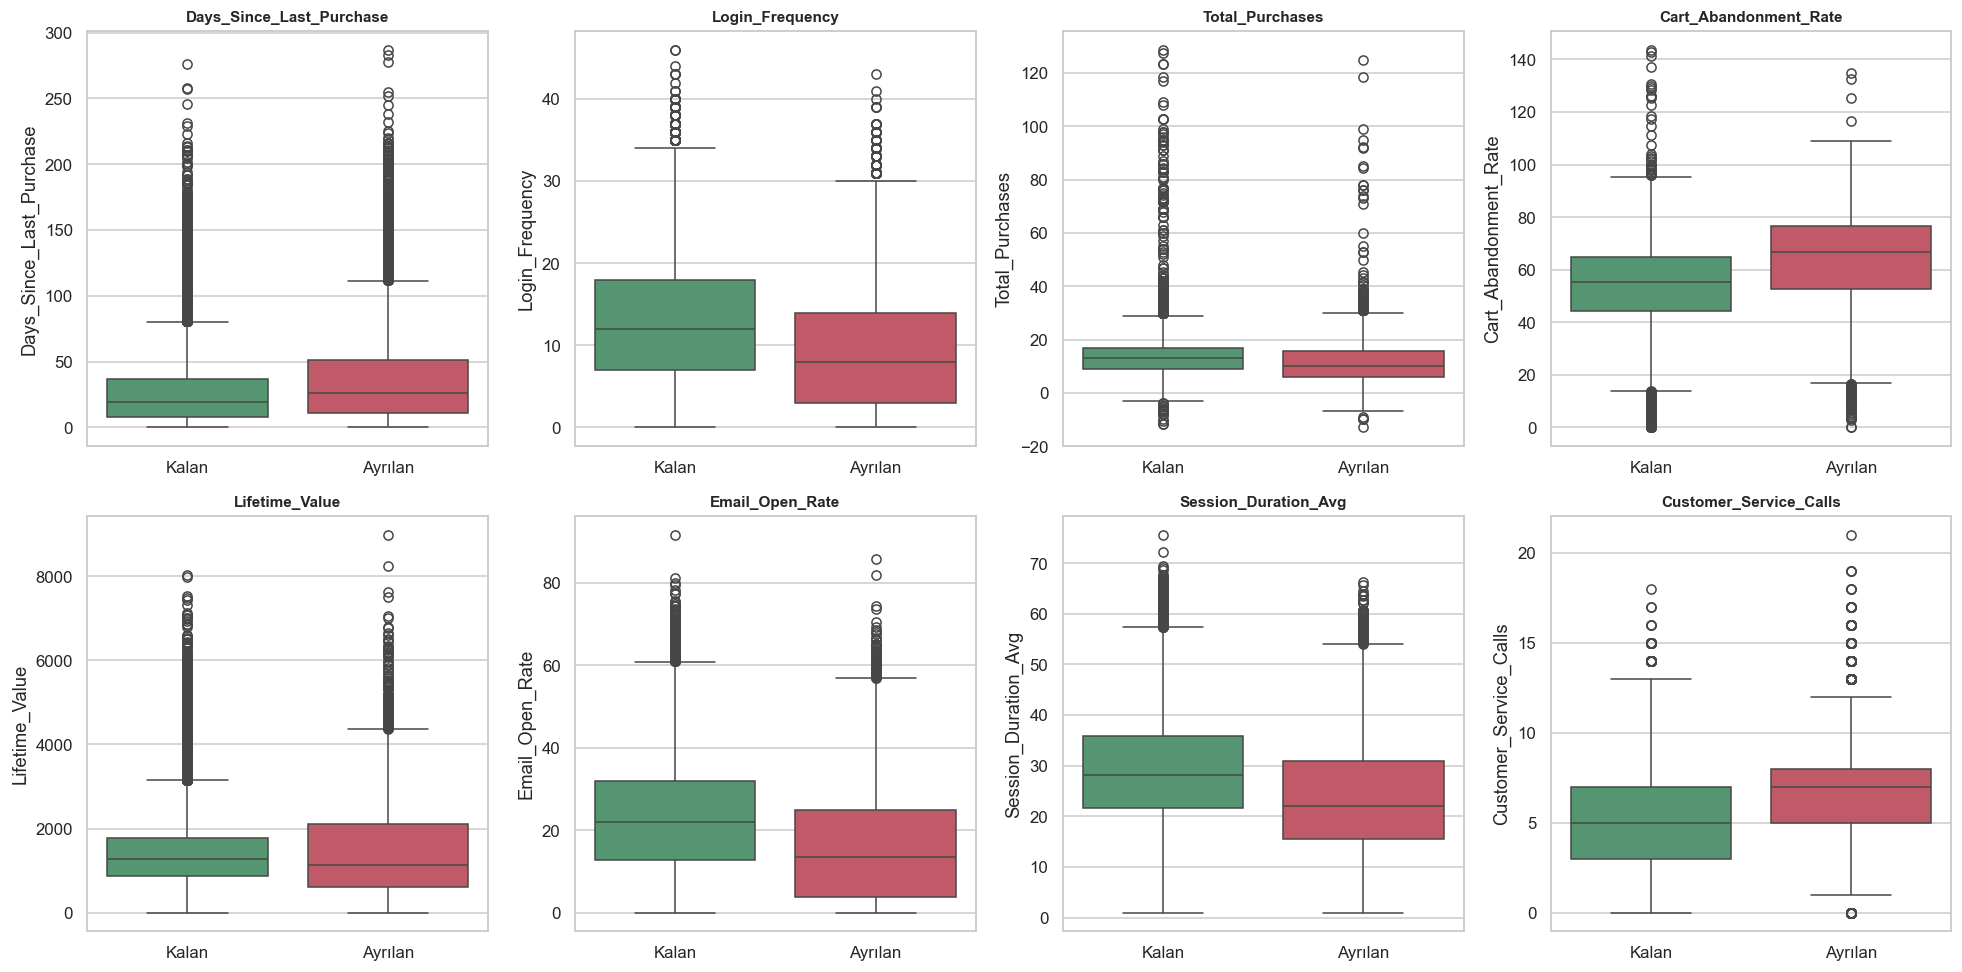

In [17]:
# Önemli sayısal değişkenlerin churn'e göre dağılımı
key_feats = ["Days_Since_Last_Purchase", "Login_Frequency", "Total_Purchases",
             "Cart_Abandonment_Rate", "Lifetime_Value", "Email_Open_Rate",
             "Session_Duration_Avg", "Customer_Service_Calls"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(key_feats):
    sns.boxplot(x=TARGET, y=col, data=df, hue=TARGET, palette=CHURN_PALETTE,
                legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(["Kalan", "Ayrılan"])
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

## 10. Davranışsal İçgörüler — RFM Bakışı

Recency (`Days_Since_Last_Purchase`), Frequency (`Total_Purchases`) ve Monetary
(`Lifetime_Value`) eksenlerinde müşteri davranışı ve churn ilişkisi. Segmentasyon
çalışmasının temelini bu üç eksen oluşturur.

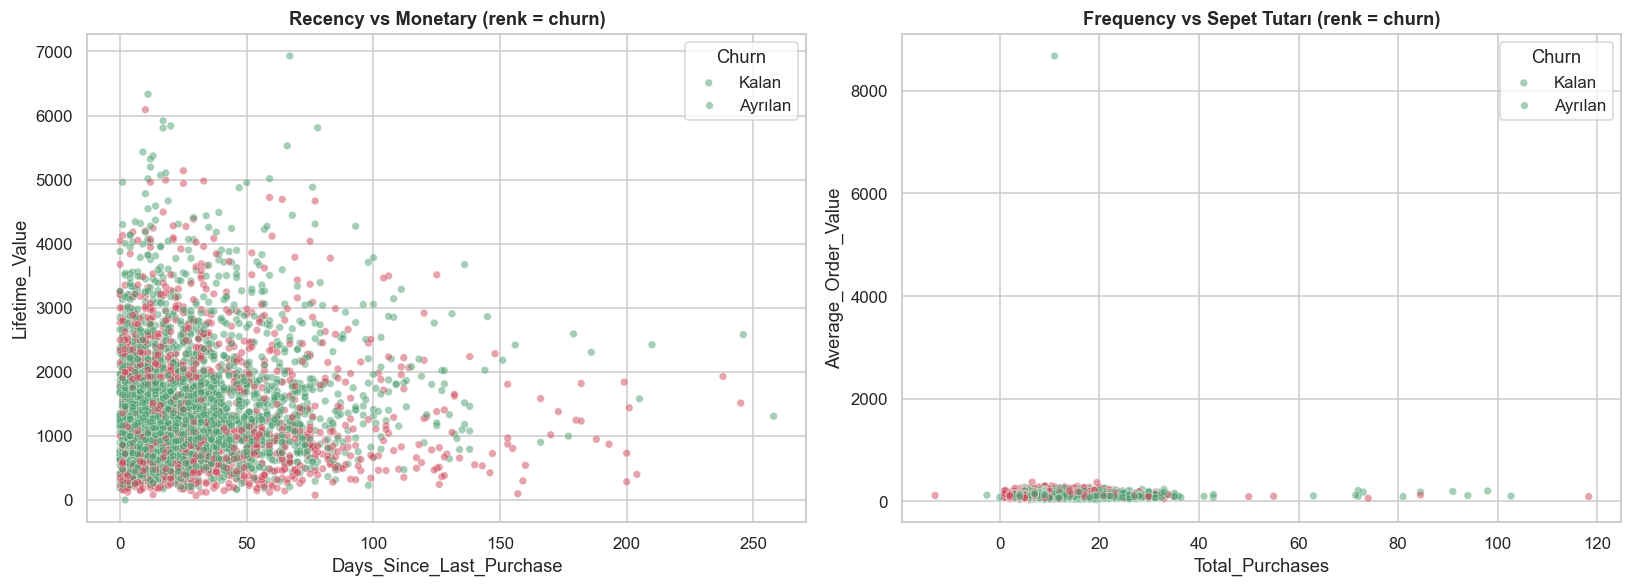

In [18]:
sample = df.dropna(subset=["Days_Since_Last_Purchase",
                            "Total_Purchases", "Lifetime_Value"]).sample(
    min(4000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=sample, x="Days_Since_Last_Purchase", y="Lifetime_Value",
                hue=TARGET, palette=CHURN_PALETTE, alpha=0.5, s=25, ax=axes[0])
axes[0].set_title("Recency vs Monetary (renk = churn)")
axes[0].legend(title="Churn", labels=["Kalan", "Ayrılan"])

sns.scatterplot(data=sample, x="Total_Purchases", y="Average_Order_Value",
                hue=TARGET, palette=CHURN_PALETTE, alpha=0.5, s=25, ax=axes[1])
axes[1].set_title("Frequency vs Sepet Tutarı (renk = churn)")
axes[1].legend(title="Churn", labels=["Kalan", "Ayrılan"])

plt.tight_layout()
plt.show()

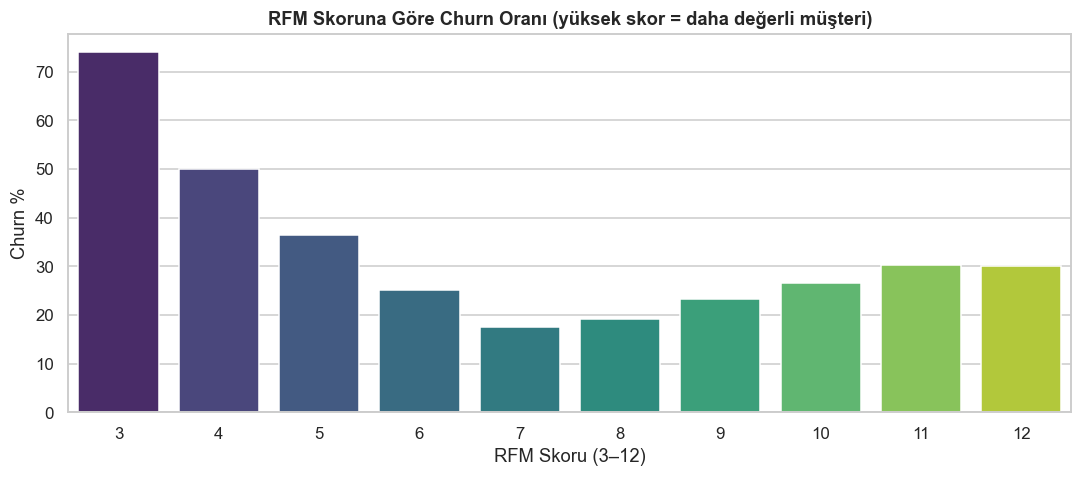

In [19]:
# Basit RFM skoru ve segment teaser'ı (çeyreklere bölerek)
rfm_cols = ["Days_Since_Last_Purchase", "Total_Purchases", "Lifetime_Value"]
rfm = df[rfm_cols].dropna().copy()   # qcut NaN ile çalışmaz -> dolu kayıtlar
rfm["R"] = pd.qcut(rfm["Days_Since_Last_Purchase"].rank(method="first"),
                   4, labels=[4, 3, 2, 1]).astype(int)   # düşük recency = iyi
rfm["F"] = pd.qcut(rfm["Total_Purchases"].rank(method="first"),
                   4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["Lifetime_Value"].rank(method="first"),
                   4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm[["R", "F", "M"]].sum(axis=1)
rfm[TARGET] = df.loc[rfm.index, TARGET]

plt.figure(figsize=(10, 4.5))
churn_by_rfm = rfm.groupby("RFM_Score")[TARGET].mean() * 100
sns.barplot(x=churn_by_rfm.index, y=churn_by_rfm.values, palette="viridis")
plt.title("RFM Skoruna Göre Churn Oranı (yüksek skor = daha değerli müşteri)")
plt.xlabel("RFM Skoru (3–12)"); plt.ylabel("Churn %")
plt.tight_layout()
plt.show()

## 11. Özet Bulgular

**Veri yapısı**
- 50.000 müşteri, 28 kolon. Hedef (`Churned`) hazır; churn oranı ≈ %29 (hafif dengesiz).
- 18 sayısal davranış özelliği, 4 kategorik (Gender, Country, City, Signup_Quarter), 3 PII.

**Veri kalitesi — modelleme öncesi temizlenmeli**
- `Age` 5–200 arası uç değerler; `Total_Purchases` negatif; `Cart_Abandonment_Rate` %100 üstü.
- %5–12 arası eksik değer birçok davranış kolonunda → imputation gerekli.

**Sızıntı (leakage) uyarısı**
- `Days_Since_Last_Purchase` / `Lifetime_Value` churn etiketinin tanımına bağlı olarak hedefi
  sızdırabilir. Korelasyon yüksekse etiketin nasıl üretildiğini doğrulamadan modele koyma.

**Sonraki adımlar**
1. Temizlik + imputation pipeline'ı
2. Churn tahmini (CatBoost/XGBoost, PR-AUC, SHAP)
3. Segmentasyon (RFM + K-Means/GMM)
4. Davranış analizi → türetilmiş engagement feature'ları
